### Iterative workflow
A workflow that loops — it keeps running until some condition is met, instead of just going start to end once.

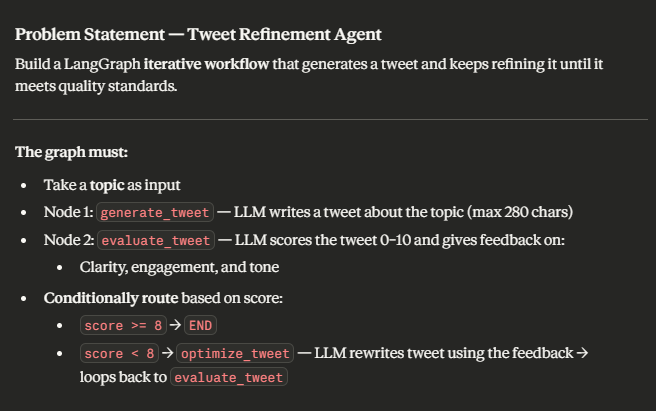

In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

load_dotenv()

# initialize the model
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=1.0,  
    max_tokens=None,
    timeout=None 
)

# evaluation LLM output structure defining
class EvalOutputSchema(BaseModel):
    score: int
    feedback: str
    evaluation: Literal["approved", "needs_improvement"]

structured_evaluation_output = model.with_structured_output(EvalOutputSchema)

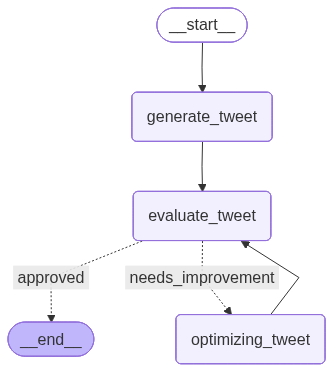

In [5]:
# define the state

class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation_feedback: str
    score: int
    iterations: int
    max_iteration: int
    evaluation: Literal["approved", "needs_improvement"]

# define the graph
graph = StateGraph(TweetState)

# make the node functions
def generate_tweet(state: TweetState) -> TweetState:
    topic = state['topic']
    prompt = f'generate a tweet of max 300 chars on topic: {topic}'
    response = model.invoke(prompt).content
    return {'tweet': response}

def evaluate_tweet(state: TweetState) -> TweetState:
    tweet = state['tweet']
    prompt = f"""
    You are a critical social media expert. Evaluate this tweet strictly:
    
    TWEET: {tweet}
    
    Score it 0-10 based on these criteria:
    - Clarity: Is the message clear and easy to understand?
    - Engagement: Does it hook the reader? Is it shareable?
    - Originality: Is it creative or generic/boring?
    - Tone: Is it conversational and human, not robotic?
    - Length: Is it punchy and concise, not padded?

    Only give 8+ if the tweet is genuinely excellent.
    A generic or bland tweet should score 4-6.
    Give specific actionable feedback on exactly what to improve.
    Along with that Respond evaluation: "approved" or "needs_improvement" 
    """
    response = structured_evaluation_output.invoke(prompt)
    return {'evaluation_feedback': response.feedback, 'score': response.score, 'evaluation': response.evaluation}

def optimize_tweet(state: TweetState) -> TweetState:
    tweet = state['tweet']
    score = state['score']
    feedback = state['evaluation_feedback']
    topic = state['topic']
    
    prompt = f"""
    This tweet about {topic} scored {score}/10.
    
    ORIGINAL TWEET: {tweet}
    
    FEEDBACK: {feedback}
    
    Rewrite the tweet addressing all the feedback above.
    Make it more engaging, punchy and original.
    Keep it under 280 characters.
    Only return the improved tweet, nothing else.
    """
    response = model.invoke(prompt).content
    iterations = state['iterations']+1
    return {'tweet': response, 'iterations':iterations}

# checker condition
def route_evaluation(state: TweetState) -> Literal["approved", "needs_improvement"]:
    if state['evaluation'] == 'approved' or state['iterations'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

# make the nodes
graph.add_node("generate_tweet", generate_tweet)
graph.add_node("evaluate_tweet", evaluate_tweet)
graph.add_node("optimizing_tweet", optimize_tweet)

# make the edges
graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet", "evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet", route_evaluation, {'approved': END, 'needs_improvement': 'optimizing_tweet'})
graph.add_edge("optimizing_tweet", "evaluate_tweet")

workflow = graph.compile()

# step - 4 : visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [6]:
initial_state = {
    'topic': 'AGI',
    'iterations': 0,
    'max_iteration':5
}

result = workflow.invoke(initial_state)
result

{'topic': 'AGI',
 'tweet': "AGI: AI capable of learning & mastering *any* intellectual task, just like a human. It's the ultimate breakthrough. But if it's the last invention humanity ever makes, who truly steers the future? Are we ready for an autonomous mind that transcends human limits—and perhaps, human relevance? #AGI #AI",
 'evaluation_feedback': "This tweet is excellent. It clearly defines AGI, immediately pivots to profound, engaging questions about its long-term implications, and maintains a conversational tone. It's highly shareable and thought-provoking, making it a strong piece of content. No specific improvements are needed; it effectively achieves its goal.",
 'score': 9,
 'iterations': 1,
 'max_iteration': 5,
 'evaluation': 'approved'}